In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project"
)

DATA_ROOT = DRIVE_ROOT / "data"
RAW_ROOT = DATA_ROOT / "raw"
PROCESSED_ROOT = DATA_ROOT / "processed"
SPLITS_ROOT = DATA_ROOT / "splits"

CHECKPOINT_ROOT = DRIVE_ROOT / "checkpoints"
GENERATED_ROOT = DRIVE_ROOT / "generated"
RESULTS_ROOT = DRIVE_ROOT / "results"
NOTEBOOK_ROOT = DRIVE_ROOT / "notebooks"

print("Project root exists:", DRIVE_ROOT.exists())
print("Raw data exists:", RAW_ROOT.exists())
print("Project root:", DRIVE_ROOT)
print("Raw data root:", RAW_ROOT)

Project root exists: True
Raw data exists: True
Project root: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project
Raw data root: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/raw


In [4]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project"
)

# Main folders
DATA_ROOT = PROJECT_ROOT / "data"
RAW_ROOT = DATA_ROOT / "raw"
PROCESSED_ROOT = DATA_ROOT / "processed"
SPLITS_ROOT = DATA_ROOT / "splits"

CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints"
GENERATED_ROOT = PROJECT_ROOT / "generated"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks"
RESULTS_ROOT = PROJECT_ROOT / "results"

# GitHub repositories
GITHUB_ROOT = PROJECT_ROOT / "github"
ORIGINAL_REPO = GITHUB_ROOT / "original"
OUR_REPO = GITHUB_ROOT / "our"

paths = {
    "PROJECT_ROOT": PROJECT_ROOT,
    "RAW_ROOT": RAW_ROOT,
    "PROCESSED_ROOT": PROCESSED_ROOT,
    "SPLITS_ROOT": SPLITS_ROOT,
    "CHECKPOINT_ROOT": CHECKPOINT_ROOT,
    "GENERATED_ROOT": GENERATED_ROOT,
    "NOTEBOOK_ROOT": NOTEBOOK_ROOT,
    "RESULTS_ROOT": RESULTS_ROOT,
    "ORIGINAL_REPO": ORIGINAL_REPO,
    "OUR_REPO": OUR_REPO,
}

for name, path in paths.items():
    print(f"{name:20s}: {path}")
    print(f"{'':20s}  exists = {path.exists()}")

PROJECT_ROOT        : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project
                      exists = True
RAW_ROOT            : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/raw
                      exists = True
PROCESSED_ROOT      : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/processed
                      exists = True
SPLITS_ROOT         : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/splits
                      exists = True
CHECKPOINT_ROOT     : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/checkpoints
                      exists = True
GENERATED_ROOT      : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/generated
                      exists = True
NOTEBOOK_ROOT       : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/notebooks
                      exists = True
RESULTS_ROOT        : /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/results
                      exists = True
ORIGINAL_REPO       

In [6]:
import subprocess

ORIGINAL_URL = "https://github.com/Miretpl/synthetic-brain-mri-project.git"

if (ORIGINAL_REPO / ".git").exists():
    print("Original repository already cloned.")
    subprocess.run(
        ["git", "-C", str(ORIGINAL_REPO), "pull"],
        check=True
    )
elif any(ORIGINAL_REPO.iterdir()):
    print(
        "The original folder is not empty, but it is not a Git repository.\n"
        "Please empty it before cloning."
    )
else:
    subprocess.run(
        ["git", "clone", ORIGINAL_URL, str(ORIGINAL_REPO)],
        check=True
    )

In [7]:
OUR_URL = (
    "https://github.com/Kaveh-Moradkhani/"
    "brain-mri-synthetic-augmentation.git"
)

if (OUR_REPO / ".git").exists():
    print("Your repository already cloned.")
    subprocess.run(
        ["git", "-C", str(OUR_REPO), "pull"],
        check=True
    )
elif any(OUR_REPO.iterdir()):
    print(
        "The 'our' folder is not empty, but it is not a Git repository.\n"
        "Please empty it before cloning."
    )
else:
    subprocess.run(
        ["git", "clone", OUR_URL, str(OUR_REPO)],
        check=True
    )

In [8]:
import shutil

LOCAL_OUR_REPO = Path(
    "/content/brain-mri-synthetic-augmentation"
)

if LOCAL_OUR_REPO.exists():
    shutil.rmtree(LOCAL_OUR_REPO)

shutil.copytree(
    OUR_REPO,
    LOCAL_OUR_REPO,
    ignore=shutil.ignore_patterns(".git")
)

print("Local working copy:", LOCAL_OUR_REPO)


Local working copy: /content/brain-mri-synthetic-augmentation


In [9]:
LOCAL_ORIGINAL_REPO = Path(
    "/content/synthetic-brain-mri-project"
)

if LOCAL_ORIGINAL_REPO.exists():
    shutil.rmtree(LOCAL_ORIGINAL_REPO)

shutil.copytree(
    ORIGINAL_REPO,
    LOCAL_ORIGINAL_REPO,
    ignore=shutil.ignore_patterns(".git")
)

print("Local original copy:", LOCAL_ORIGINAL_REPO)

Local original copy: /content/synthetic-brain-mri-project


In [10]:
gitignore_path = OUR_REPO / ".gitignore"

gitignore_content = """
# Google Colab and Jupyter
.ipynb_checkpoints/
**/.ipynb_checkpoints/

# Medical image data
*.nii
*.nii.gz

# Model checkpoints
*.pt
*.pth
*.ckpt
*.safetensors

# Data and experiment outputs
data/raw/
data/processed/
checkpoints/
generated/
results/

# Python
__pycache__/
*.pyc
.venv/
env/

# System files
.DS_Store
""".strip()

gitignore_path.write_text(
    gitignore_content + "\n",
    encoding="utf-8"
)

print(gitignore_path.read_text())

# Google Colab and Jupyter
.ipynb_checkpoints/
**/.ipynb_checkpoints/

# Medical image data
*.nii
*.nii.gz

# Model checkpoints
*.pt
*.pth
*.ckpt
*.safetensors

# Data and experiment outputs
data/raw/
data/processed/
checkpoints/
generated/
results/

# Python
__pycache__/
*.pyc
.venv/
env/

# System files
.DS_Store



In [11]:
patient_dirs = sorted(
    path
    for path in RAW_ROOT.glob("BraTS2021_*")
    if path.is_dir()
)

print("Raw root:", RAW_ROOT)
print("Number of patients:", len(patient_dirs))

for patient in patient_dirs[:10]:
    print(patient.name)

Raw root: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/raw
Number of patients: 1251
BraTS2021_00000
BraTS2021_00002
BraTS2021_00003
BraTS2021_00005
BraTS2021_00006
BraTS2021_00008
BraTS2021_00009
BraTS2021_00011
BraTS2021_00012
BraTS2021_00014


In [12]:
if not patient_dirs:
    raise RuntimeError(
        f"No BRaTS patient folders found in:\n{RAW_ROOT}"
    )

first_patient = patient_dirs[0]

print("First patient:", first_patient.name)

for file_path in sorted(first_patient.iterdir()):
    print(" ", file_path.name)

First patient: BraTS2021_00000
  BraTS2021_00000_flair.nii.gz
  BraTS2021_00000_seg.nii.gz
  BraTS2021_00000_t1.nii.gz
  BraTS2021_00000_t1ce.nii.gz
  BraTS2021_00000_t2.nii.gz


In [13]:
%pip install -q nibabel matplotlib

In [14]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [15]:
flair_path = first_patient / f"{first_patient.name}_flair.nii.gz"
seg_path = first_patient / f"{first_patient.name}_seg.nii.gz"

print("FLAIR path:")
print(flair_path)

print("\nSegmentation path:")
print(seg_path)

print("\nFLAIR exists:", flair_path.exists())
print("Segmentation exists:", seg_path.exists())

FLAIR path:
/content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/raw/BraTS2021_00000/BraTS2021_00000_flair.nii.gz

Segmentation path:
/content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/raw/BraTS2021_00000/BraTS2021_00000_seg.nii.gz

FLAIR exists: True
Segmentation exists: True


In [16]:
flair_nii = nib.load(str(flair_path))
seg_nii = nib.load(str(seg_path))

flair = flair_nii.get_fdata(dtype=np.float32)
seg = seg_nii.get_fdata(dtype=np.float32)

print("FLAIR shape:", flair.shape)
print("Segmentation shape:", seg.shape)

print("FLAIR data type:", flair.dtype)
print("Segmentation data type:", seg.dtype)

print("FLAIR minimum:", flair.min())
print("FLAIR maximum:", flair.max())

print("Segmentation labels:", np.unique(seg))

FLAIR shape: (240, 240, 155)
Segmentation shape: (240, 240, 155)
FLAIR data type: float32
Segmentation data type: float32
FLAIR minimum: 0.0
FLAIR maximum: 2934.0
Segmentation labels: [0. 1. 2. 4.]


In [17]:
print("FLAIR affine:")
print(flair_nii.affine)

print("\nSegmentation affine:")
print(seg_nii.affine)

print(
    "\nAffines match:",
    np.allclose(flair_nii.affine, seg_nii.affine)
)

print(
    "Shapes match:",
    flair.shape == seg.shape
)

FLAIR affine:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Segmentation affine:
[[ -1.  -0.  -0.  -0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Affines match: True
Shapes match: True


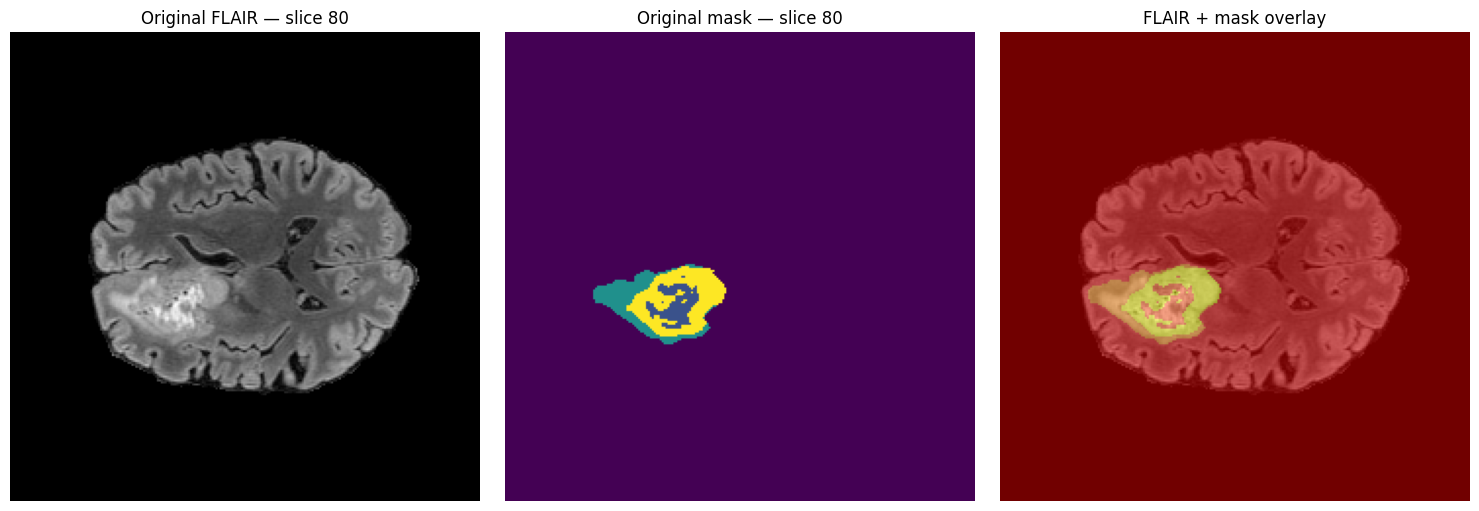

In [18]:
slice_index = 80

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(flair[:, :, slice_index], cmap="gray")
axes[0].set_title(f"Original FLAIR — slice {slice_index}")
axes[0].axis("off")

axes[1].imshow(seg[:, :, slice_index], cmap="viridis")
axes[1].set_title(f"Original mask — slice {slice_index}")
axes[1].axis("off")

axes[2].imshow(flair[:, :, slice_index], cmap="gray")
axes[2].imshow(
    seg[:, :, slice_index],
    cmap="autumn",
    alpha=0.45,
    vmin=0,
    vmax=4,
)
axes[2].set_title("FLAIR + mask overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [19]:
flair.shape

(240, 240, 155)

In [20]:
flair_selected = flair[40:200, 11:235, 20:140:20]
seg_selected = seg[40:200, 11:235, 20:140:20]

print("Selected FLAIR shape:", flair_selected.shape)
print("Selected mask shape:", seg_selected.shape)

Selected FLAIR shape: (160, 224, 6)
Selected mask shape: (160, 224, 6)


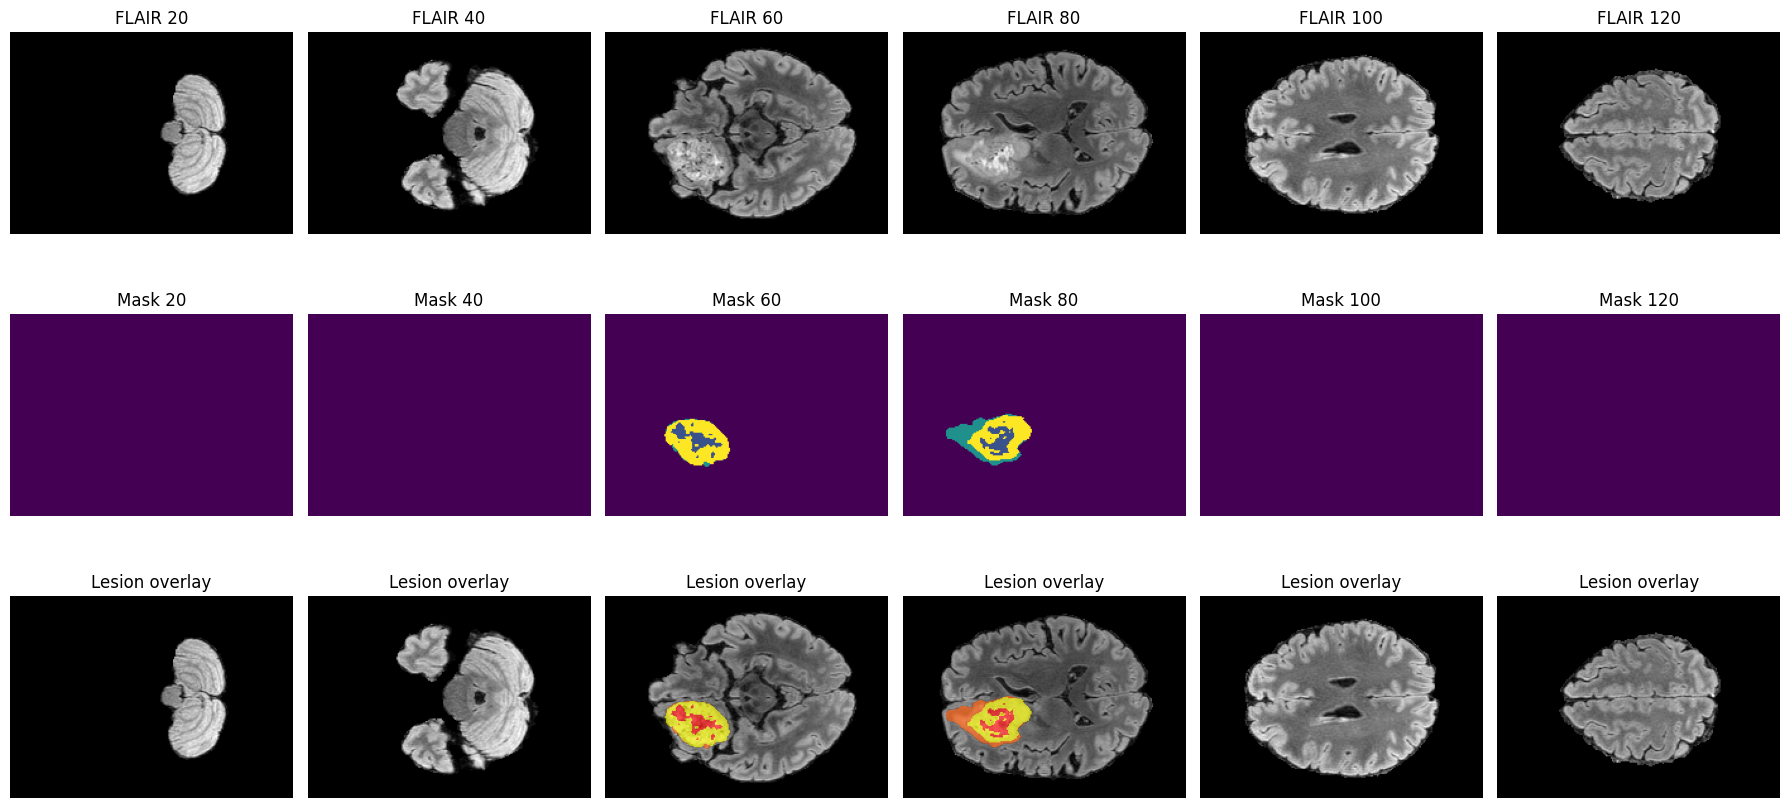

In [24]:
selected_slice_indices = list(range(20, 140, 20))

fig, axes = plt.subplots(
    3,
    len(selected_slice_indices),
    figsize=(18, 9)
)

for column, original_slice_index in enumerate(selected_slice_indices):
    flair_slice = flair_selected[:, :, column]
    seg_slice = seg_selected[:, :, column]

    # Hide background label 0
    visible_seg = np.ma.masked_equal(seg_slice, 0)

    axes[0, column].imshow(flair_slice, cmap="gray")
    axes[0, column].set_title(f"FLAIR {original_slice_index}")
    axes[0, column].axis("off")

    axes[1, column].imshow(
        seg_slice,
        cmap="viridis",
        vmin=0,
        vmax=4,
    )
    axes[1, column].set_title(f"Mask {original_slice_index}")
    axes[1, column].axis("off")

    axes[2, column].imshow(flair_slice, cmap="gray")
    axes[2, column].imshow(
        visible_seg,
        cmap="autumn",
        alpha=0.65,
        vmin=1,
        vmax=4,
    )
    axes[2, column].set_title("Lesion overlay")
    axes[2, column].axis("off")

plt.tight_layout()
plt.show()

In [22]:
for local_index, original_slice_index in enumerate(selected_slice_indices):
    mask_slice = seg_selected[:, :, local_index]

    labels = np.unique(mask_slice)
    lesion_pixels = np.count_nonzero(mask_slice)

    print(
        f"Original slice {original_slice_index:3d} | "
        f"labels = {labels} | "
        f"lesion pixels = {lesion_pixels}"
    )

Original slice  20 | labels = [0.] | lesion pixels = 0
Original slice  40 | labels = [0.] | lesion pixels = 0
Original slice  60 | labels = [0. 1. 2. 4.] | lesion pixels = 1414
Original slice  80 | labels = [0. 1. 2. 4.] | lesion pixels = 1759
Original slice 100 | labels = [0.] | lesion pixels = 0
Original slice 120 | labels = [0.] | lesion pixels = 0


In [23]:
assert flair.shape == seg.shape
assert flair_selected.shape == (160, 224, 6)
assert seg_selected.shape == (160, 224, 6)
assert np.isfinite(flair_selected).all()
assert np.isfinite(seg_selected).all()

print("All preprocessing checks passed.")

All preprocessing checks passed.


In [25]:
def normalize_to_uint8(volume: np.ndarray) -> np.ndarray:
    """Normalize a volume globally to the uint8 range [0, 255]."""
    volume = volume.astype(np.float32)

    minimum = float(volume.min())
    maximum = float(volume.max())

    if np.isclose(maximum, minimum):
        return np.zeros_like(volume, dtype=np.uint8)

    normalized = (volume - minimum) / (maximum - minimum)
    return (normalized * 255).astype(np.uint8)


flair_uint8 = normalize_to_uint8(flair_selected)
original_seg_labels = seg_selected.astype(np.uint8)

print("FLAIR uint8 shape:", flair_uint8.shape)
print("FLAIR uint8 range:", flair_uint8.min(), flair_uint8.max())
print("Original labels:", np.unique(original_seg_labels))

FLAIR uint8 shape: (160, 224, 6)
FLAIR uint8 range: 0 255
Original labels: [0 1 2 4]


In [26]:
healthy_flags = [
    bool(np.isclose(original_seg_labels[:, :, i].max(), 0))
    for i in range(original_seg_labels.shape[2])
]

for slice_index, is_healthy in zip(
    selected_slice_indices,
    healthy_flags,
):
    print(
        f"Slice {slice_index:3d}: "
        f"{'healthy' if is_healthy else 'pathological'}"
    )

Slice  20: healthy
Slice  40: healthy
Slice  60: pathological
Slice  80: pathological
Slice 100: healthy
Slice 120: healthy


In [27]:
%pip install -q opencv-python-headless

In [28]:
import cv2

conditioning_labels = np.zeros_like(
    original_seg_labels,
    dtype=np.uint8,
)

brain_region_masks = np.zeros_like(
    original_seg_labels,
    dtype=np.uint8,
)

erosion_kernel = np.ones((3, 3), dtype=np.uint8)
closing_kernel = np.ones((6, 6), dtype=np.uint8)

for i in range(flair_uint8.shape[2]):
    flair_slice = flair_uint8[:, :, i]
    original_seg_slice = original_seg_labels[:, :, i]

    # 1. Convert non-background FLAIR pixels into a binary brain mask.
    _, brain_binary = cv2.threshold(
        flair_slice,
        1,
        255,
        cv2.THRESH_BINARY,
    )

    # 2. Slightly shrink the brain boundary.
    brain_binary = cv2.erode(
        brain_binary,
        erosion_kernel,
        iterations=1,
    )

    # 3. Fill small holes and connect small gaps.
    brain_binary = cv2.morphologyEx(
        brain_binary,
        cv2.MORPH_CLOSE,
        closing_kernel,
    )

    # 4. Convert the binary brain region to class 3.
    brain_class = np.where(
        brain_binary == 255,
        3,
        0,
    ).astype(np.uint8)

    brain_region_masks[:, :, i] = brain_class

    # 5. Keep tumor labels 1, 2, and 4.
    # Add class 3 only where the original segmentation is 0.
    conditioning_labels[:, :, i] = np.where(
        original_seg_slice == 0,
        brain_class,
        original_seg_slice,
    )

In [29]:
print(
    "Original segmentation labels:",
    np.unique(original_seg_labels),
)

print(
    "Brain-region labels:",
    np.unique(brain_region_masks),
)

print(
    "Final conditioning labels:",
    np.unique(conditioning_labels),
)

Original segmentation labels: [0 1 2 4]
Brain-region labels: [0 3]
Final conditioning labels: [0 1 2 3 4]


In [30]:
lesion_voxels = original_seg_labels > 0

assert np.array_equal(
    conditioning_labels[lesion_voxels],
    original_seg_labels[lesion_voxels],
)

assert set(np.unique(conditioning_labels)).issubset(
    {0, 1, 2, 3, 4}
)

print("Tumor labels were preserved correctly.")

Tumor labels were preserved correctly.


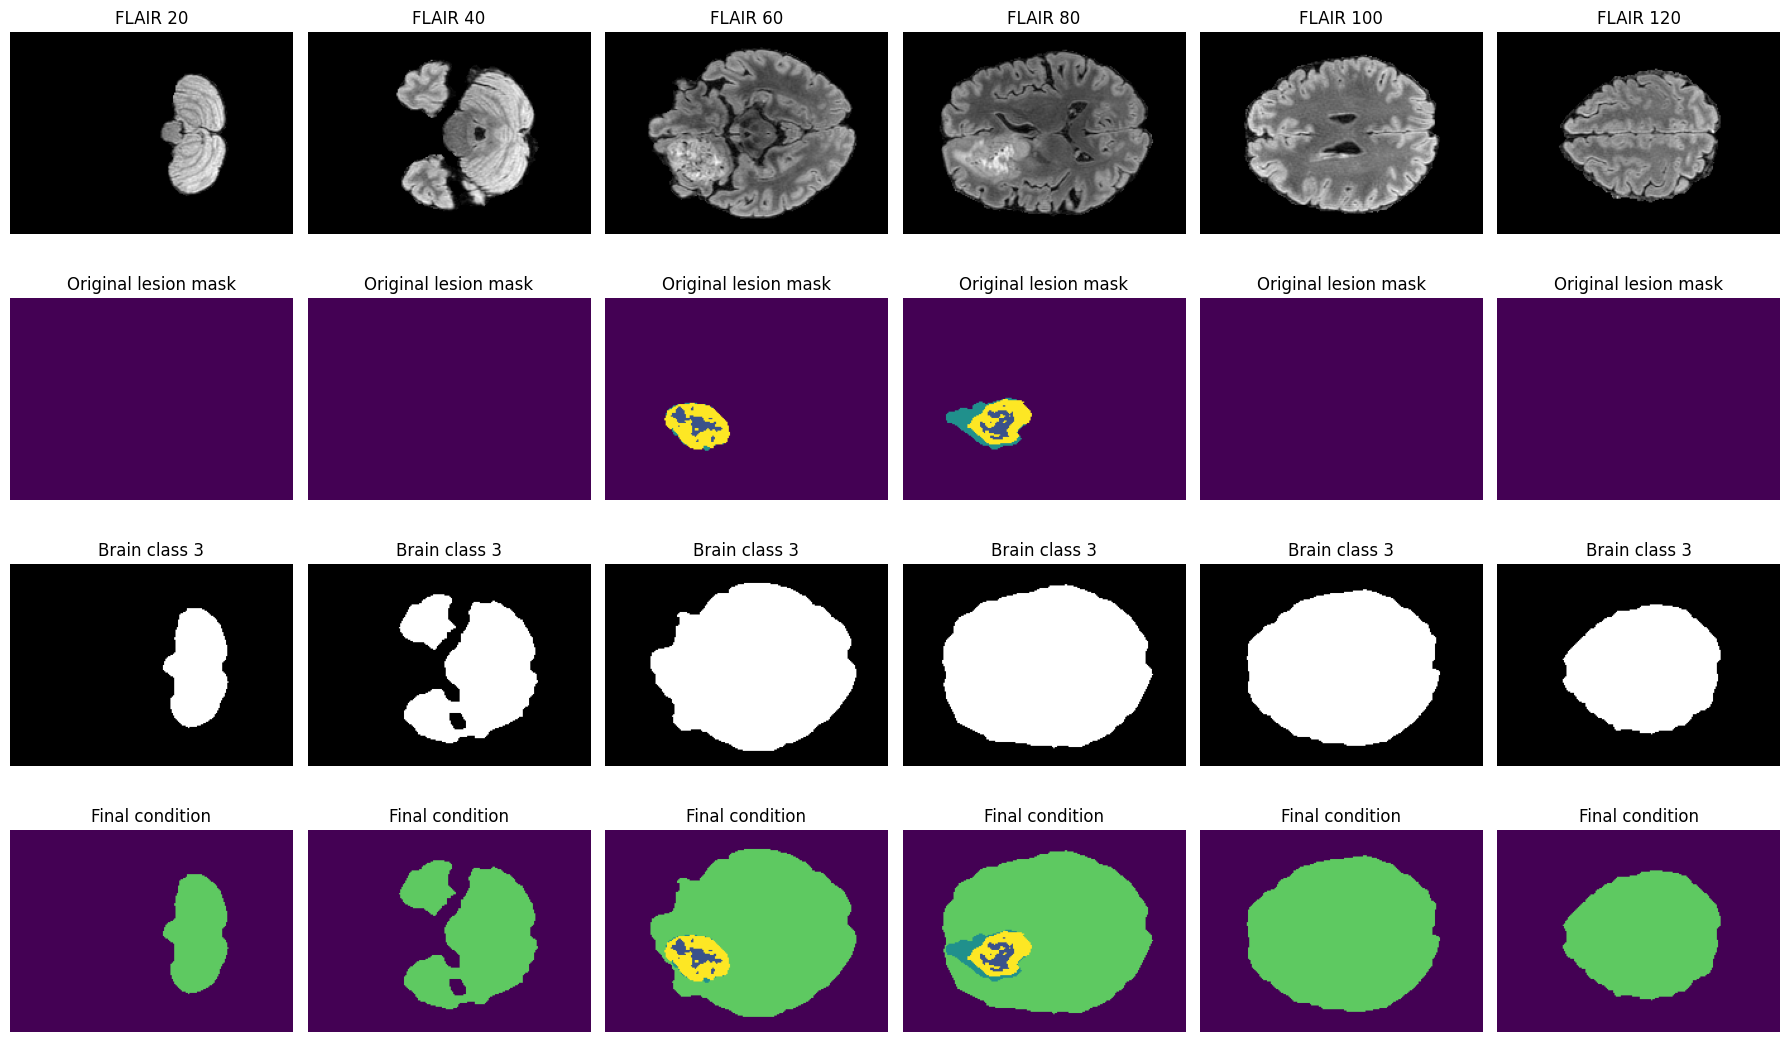

In [31]:
fig, axes = plt.subplots(
    4,
    len(selected_slice_indices),
    figsize=(18, 11),
)

for column, original_slice_index in enumerate(selected_slice_indices):
    flair_slice = flair_uint8[:, :, column]
    original_slice = original_seg_labels[:, :, column]
    brain_slice = brain_region_masks[:, :, column]
    condition_slice = conditioning_labels[:, :, column]

    axes[0, column].imshow(flair_slice, cmap="gray")
    axes[0, column].set_title(f"FLAIR {original_slice_index}")
    axes[0, column].axis("off")

    axes[1, column].imshow(
        original_slice,
        cmap="viridis",
        vmin=0,
        vmax=4,
    )
    axes[1, column].set_title("Original lesion mask")
    axes[1, column].axis("off")

    axes[2, column].imshow(
        brain_slice,
        cmap="gray",
        vmin=0,
        vmax=3,
    )
    axes[2, column].set_title("Brain class 3")
    axes[2, column].axis("off")

    axes[3, column].imshow(
        condition_slice,
        cmap="viridis",
        vmin=0,
        vmax=4,
    )
    axes[3, column].set_title("Final condition")
    axes[3, column].axis("off")

plt.tight_layout()
plt.show()

In [32]:
conditioning_png = (
    conditioning_labels.astype(np.float32) / 4.0 * 255.0
).astype(np.uint8)

print("Label-space values:", np.unique(conditioning_labels))
print("PNG pixel values:", np.unique(conditioning_png))

Label-space values: [0 1 2 3 4]
PNG pixel values: [  0  63 127 191 255]


In [34]:
from pathlib import Path

EXTRACTED_ROOT = PROCESSED_ROOT / "extracted"
GENERATION_DATA_ROOT = PROCESSED_ROOT / "generation"
METADATA_ROOT = DATA_ROOT / "metadata"

for path in [
    EXTRACTED_ROOT,
    GENERATION_DATA_ROOT,
    METADATA_ROOT,
]:
    path.mkdir(parents=True, exist_ok=True)

print("Extracted root:", EXTRACTED_ROOT)
print("Generation-data root:", GENERATION_DATA_ROOT)
print("Metadata root:", METADATA_ROOT)

Extracted root: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/processed/extracted
Generation-data root: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/processed/generation
Metadata root: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/metadata


In [35]:
def normalize_array_to_uint8(array):
    """Match the original repository's min-max PNG conversion."""
    array = array.astype(np.float32)

    minimum = float(array.min())
    maximum = float(array.max())

    if np.isclose(maximum, 0) or np.isclose(maximum, minimum):
        return np.zeros_like(array, dtype=np.uint8)

    normalized = (array - minimum) / (maximum - minimum)
    return (normalized * 255).astype(np.uint8)


original_seg_png = normalize_array_to_uint8(
    original_seg_labels
)

conditioning_seg_png = (
    conditioning_labels.astype(np.float32)
    / 4.0
    * 255.0
).astype(np.uint8)

print(
    "Original segmentation PNG values:",
    np.unique(original_seg_png),
)

print(
    "Conditioning segmentation PNG values:",
    np.unique(conditioning_seg_png),
)

Original segmentation PNG values: [  0  63 127 255]
Conditioning segmentation PNG values: [  0  63 127 191 255]


In [36]:
patient_code = first_patient.name.replace(
    "BraTS2021_",
    "",
)

extracted_patient_dir = (
    EXTRACTED_ROOT / patient_code
)

generation_patient_dir = (
    GENERATION_DATA_ROOT / patient_code
)

extracted_patient_dir.mkdir(
    parents=True,
    exist_ok=True,
)

generation_patient_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print("Patient code:", patient_code)
print("Extracted directory:", extracted_patient_dir)
print("Generation directory:", generation_patient_dir)

Patient code: 00000
Extracted directory: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/processed/extracted/00000
Generation directory: /content/drive/MyDrive/NMA-DL2026/NMA_BrainMRI_Project/data/processed/generation/00000


In [37]:
from PIL import Image

saved_files = []

for local_index, original_index in enumerate(
    selected_slice_indices
):
    status = (
        "healthy"
        if healthy_flags[local_index]
        else "unhealthy"
    )

    flair_filename = (
        f"{local_index:02d}_flair_{status}.png"
    )

    seg_filename = (
        f"{local_index:02d}_seg_{status}.png"
    )

    flair_slice = flair_uint8[:, :, local_index]

    original_seg_slice = (
        original_seg_png[:, :, local_index]
    )

    conditioning_seg_slice = (
        conditioning_seg_png[:, :, local_index]
    )

    # Dataset for downstream segmentation
    Image.fromarray(flair_slice).save(
        extracted_patient_dir / flair_filename
    )

    Image.fromarray(original_seg_slice).save(
        extracted_patient_dir / seg_filename
    )

    # Dataset for training generative models
    Image.fromarray(flair_slice).save(
        generation_patient_dir / flair_filename
    )

    Image.fromarray(conditioning_seg_slice).save(
        generation_patient_dir / seg_filename
    )

    saved_files.append(
        {
            "local_index": local_index,
            "original_index": original_index,
            "status": status,
            "flair_filename": flair_filename,
            "seg_filename": seg_filename,
        }
    )

print("One patient was saved successfully.")

One patient was saved successfully.


In [38]:
test_flair_path = (
    generation_patient_dir
    / "02_flair_unhealthy.png"
)

test_condition_path = (
    generation_patient_dir
    / "02_seg_unhealthy.png"
)

saved_flair = np.asarray(
    Image.open(test_flair_path)
)

saved_condition = np.asarray(
    Image.open(test_condition_path)
)

print("Saved FLAIR shape:", saved_flair.shape)
print("Saved FLAIR dtype:", saved_flair.dtype)
print("Saved FLAIR range:", saved_flair.min(), saved_flair.max())

print("\nSaved condition shape:", saved_condition.shape)
print("Saved condition dtype:", saved_condition.dtype)
print(
    "Saved condition values:",
    np.unique(saved_condition),
)

Saved FLAIR shape: (160, 224)
Saved FLAIR dtype: uint8
Saved FLAIR range: 0 217

Saved condition shape: (160, 224)
Saved condition dtype: uint8
Saved condition values: [  0  63 127 191 255]


In [39]:
extracted_mask = np.asarray(
    Image.open(
        extracted_patient_dir
        / "02_seg_unhealthy.png"
    )
)

generation_mask = np.asarray(
    Image.open(
        generation_patient_dir
        / "02_seg_unhealthy.png"
    )
)

print(
    "Extracted mask values:",
    np.unique(extracted_mask),
)

print(
    "Generation mask values:",
    np.unique(generation_mask),
)

print(
    "Masks are identical:",
    np.array_equal(
        extracted_mask,
        generation_mask,
    ),
)

Extracted mask values: [  0  63 127 255]
Generation mask values: [  0  63 127 191 255]
Masks are identical: False


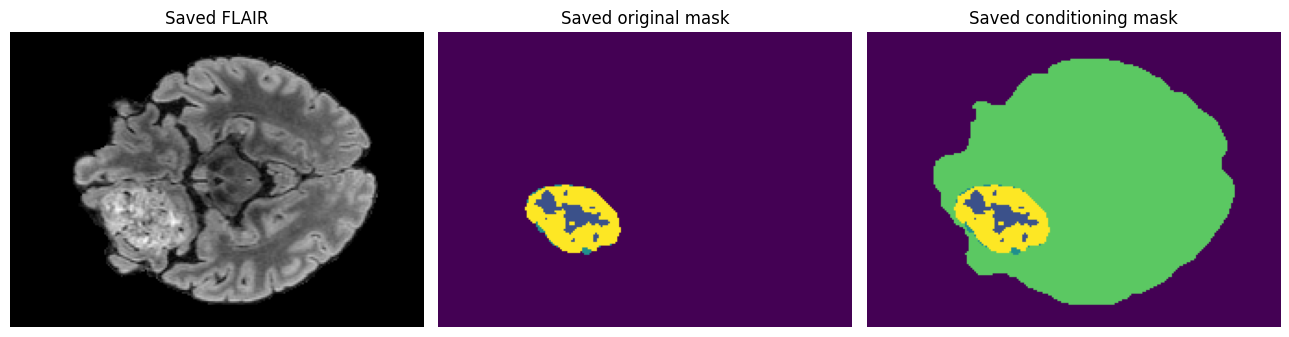

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(saved_flair, cmap="gray")
axes[0].set_title("Saved FLAIR")
axes[0].axis("off")

axes[1].imshow(
    extracted_mask,
    cmap="viridis",
    vmin=0,
    vmax=255,
)
axes[1].set_title("Saved original mask")
axes[1].axis("off")

axes[2].imshow(
    generation_mask,
    cmap="viridis",
    vmin=0,
    vmax=255,
)
axes[2].set_title("Saved conditioning mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [41]:
extracted_files = sorted(
    extracted_patient_dir.glob("*.png")
)

generation_files = sorted(
    generation_patient_dir.glob("*.png")
)

assert len(extracted_files) == 12
assert len(generation_files) == 12

assert saved_flair.shape == (160, 224)
assert saved_condition.shape == (160, 224)

assert saved_flair.dtype == np.uint8
assert saved_condition.dtype == np.uint8

assert set(np.unique(saved_condition)).issubset(
    {0, 63, 127, 191, 255}
)

print("One-patient saving and verification passed.")

One-patient saving and verification passed.
